# ORIENT'IA — Exploration, Modélisation & Analyse de Biais

Démarche scientifique (Phase 2 du sujet) : exploration, nettoyage,
choix de variables, split train/test, baseline, comparaison de 2 modèles,
métriques sérieuses, visualisations graphiques et sauvegarde du modèle.

Données : `data/synthetique/dataset_orientia_synthetique.csv` (synthétiques, documentées).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from pathlib import Path

from config import config
from services import ml_features, ml_service
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, accuracy_score, log_loss, confusion_matrix
)

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#3a3a5c', 'axes.labelcolor': '#e0e0f0', 'xtick.color': '#e0e0f0',
    'ytick.color': '#e0e0f0', 'text.color': '#e0e0f0', 'grid.color': '#2a2a4a',
    'font.family': 'DejaVu Sans', 'font.size': 10
})
PALETTE = ['#7c5cbf','#3daee9','#27ae60','#e74c3c','#f39c12','#1abc9c',
           '#9b59b6','#e67e22','#16a085','#2980b9','#8e44ad','#c0392b',
           '#d35400','#2ecc71','#2c3e50','#f1c40f']

df = ml_service.load_dataset()
print(f'Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head(3)

Dataset chargé : 400 lignes × 65 colonnes


,id_anonyme,type_repondant,sexe,serie_bac,famille_bac,note_malagasy,note_francais,note_langue_vivante,note_hg,note_philosophie,...,prerequis_anglais,prerequis_maths_avancees,parcours_choisi,niveau_actuel,annee_fin_etudes,metier_exerce,anciennete_metier,satisfaction,referait_choix,commentaire_retrospectif
0,rep_synth_0009,etudiant,homme,s,scientifique,10,9,9,9,4,...,1,1,icmp,l2,0,NaN,NaN,4,oui,NaN
1,rep_synth_0193,etudiant,homme,s,scientifique,6,12,9,9,10,...,0,1,emii,m1,0,NaN,NaN,5,oui,NaN
2,rep_synth_0132,etudiant,homme,s,scientifique,7,13,9,12,7,...,1,1,isaia,m2,0,NaN,NaN,5,oui,NaN


## 1. Exploration — Distributions

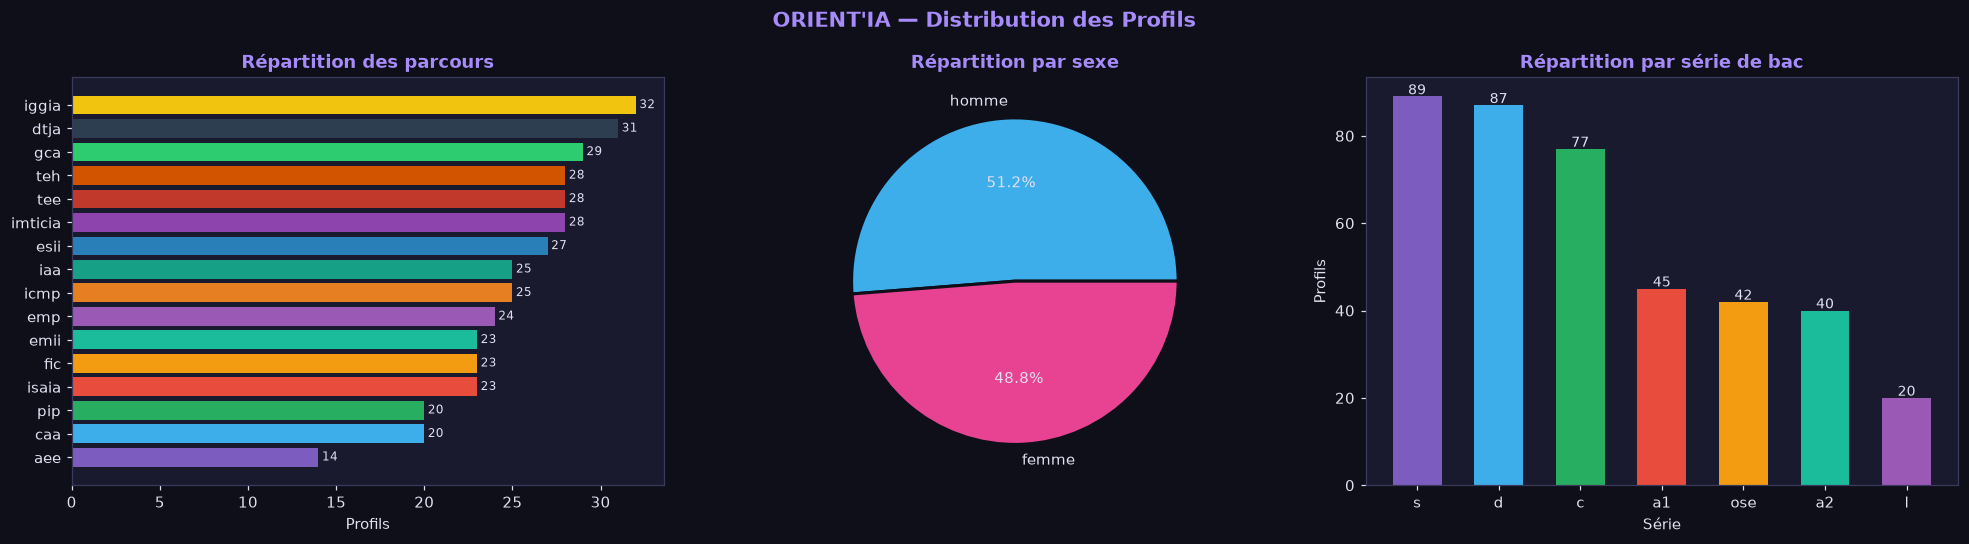

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ORIENT'IA — Distribution des Profils", fontsize=14, fontweight='bold', color='#a78bfa')

# Parcours
pc = df['parcours_choisi'].value_counts().sort_values(ascending=True)
colors = [PALETTE[i % len(PALETTE)] for i in range(len(pc))]
axes[0].barh(pc.index, pc.values, color=colors, edgecolor='none')
axes[0].set_title('Répartition des parcours', color='#a78bfa', fontweight='bold')
axes[0].set_xlabel('Profils')
for v, bar in zip(pc.values, axes[0].patches):
    axes[0].text(v+0.2, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=8)

# Sexe
if 'sexe' in df.columns:
    sc = df['sexe'].value_counts()
else:
    sc = pd.Series({'N/A': len(df)})
axes[1].pie(sc.values, labels=sc.index, autopct='%1.1f%%',
            colors=['#3daee9','#e84393'], textprops={'color':'#e0e0f0'},
            wedgeprops={'edgecolor':'#0f0f1a','linewidth':2})
axes[1].set_title('Répartition par sexe', color='#a78bfa', fontweight='bold')

# Série
src = df['serie_bac'].value_counts()
axes[2].bar(src.index, src.values, color=PALETTE[:len(src)], edgecolor='none', width=0.6)
axes[2].set_title('Répartition par série de bac', color='#a78bfa', fontweight='bold')
axes[2].set_xlabel('Série')
axes[2].set_ylabel('Profils')
for i, v in enumerate(src.values):
    axes[2].text(i, v+0.5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 2. Features & Valeurs Manquantes

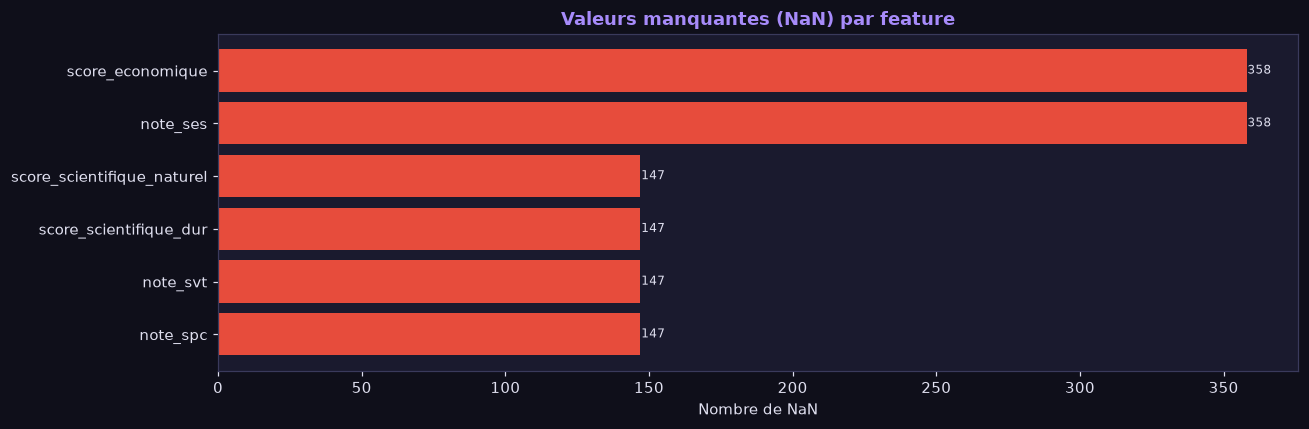

Features totales : 77  |  Features avec NaN : 6


In [3]:
X = ml_features.df_to_features(df)
y = df[ml_service.CIBLE].astype(str)
feature_names = ml_features.feature_names()

nan_s = pd.Series(np.isnan(X).sum(axis=0), index=feature_names)
nan_nz = nan_s[nan_s > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, max(4, len(nan_nz)*0.4)))
ax.barh(nan_nz.index, nan_nz.values, color='#e74c3c', edgecolor='none')
ax.set_title('Valeurs manquantes (NaN) par feature', color='#a78bfa', fontweight='bold')
ax.set_xlabel('Nombre de NaN')
for v, bar in zip(nan_nz.values, ax.patches):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()
print(f'Features totales : {X.shape[1]}  |  Features avec NaN : {(nan_s>0).sum()}')

## 3. Entraînement — Baseline vs RandomForest vs LogisticRegression

In [4]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
imputer = SimpleImputer(strategy='median').fit(Xtr)
Xtr_imp = imputer.transform(Xtr)
Xte_imp = imputer.transform(Xte)

baseline = DummyClassifier(strategy='most_frequent').fit(Xtr, ytr)
rf  = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced').fit(Xtr, ytr)
lr  = LogisticRegression(max_iter=3000, random_state=42).fit(Xtr_imp, ytr)

resultats = {}
for nom, m, Xte_m in [('Baseline', baseline, Xte), ('RandomForest', rf, Xte), ('LogisticReg', lr, Xte_imp)]:
    yp  = m.predict(Xte_m)
    ypp = m.predict_proba(Xte_m)
    acc = accuracy_score(yte, yp)
    ll  = log_loss(yte, ypp, labels=sorted(m.classes_))
    resultats[nom] = {'accuracy': acc, 'log_loss': ll}
    print(f'{nom:14s}  accuracy={acc:.3f}   log_loss={ll:.3f}')

print('\n✓ Modèles entraînés.')

Baseline        accuracy=0.075   log_loss=33.340
RandomForest    accuracy=0.825   log_loss=0.675
LogisticReg     accuracy=0.800   log_loss=0.584

✓ Modèles entraînés.


## 4. Comparaison des Modèles

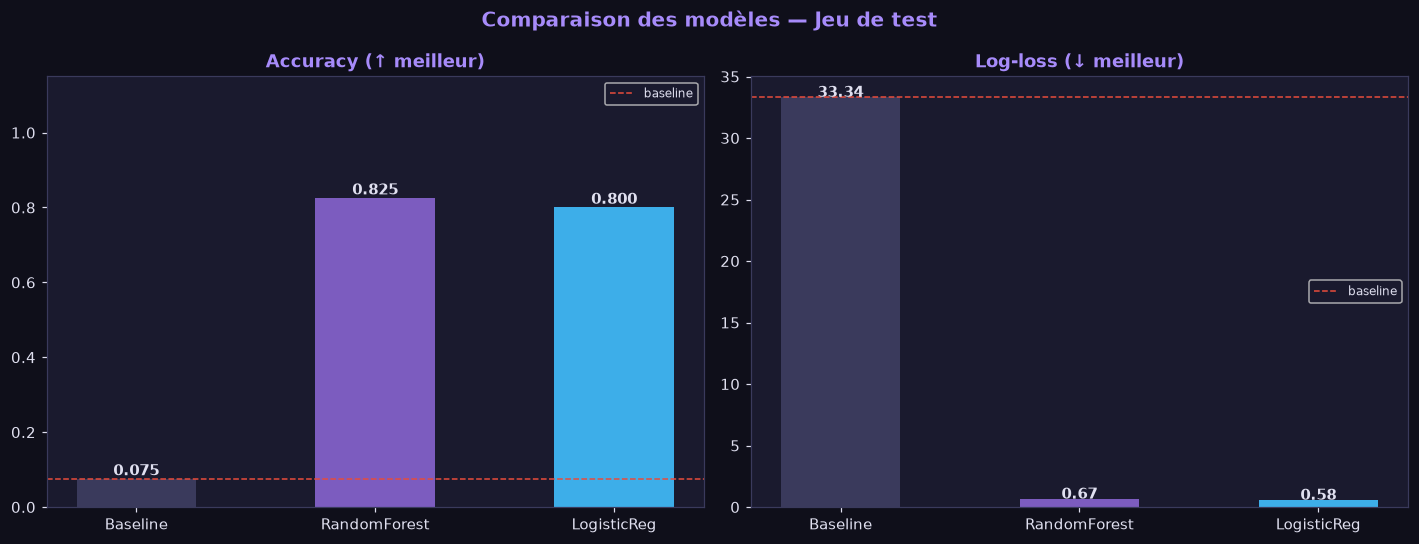

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparaison des modèles — Jeu de test', fontsize=13, fontweight='bold', color='#a78bfa')

noms = list(resultats.keys())
accs = [resultats[n]['accuracy'] for n in noms]
lls  = [resultats[n]['log_loss']  for n in noms]
bar_colors = ['#3a3a5c', '#7c5cbf', '#3daee9']

bars0 = axes[0].bar(noms, accs, color=bar_colors, edgecolor='none', width=0.5)
axes[0].set_title('Accuracy (↑ meilleur)', color='#a78bfa', fontweight='bold')
axes[0].set_ylim(0, 1.15)
axes[0].axhline(accs[0], linestyle='--', color='#e74c3c', linewidth=1, label='baseline')
axes[0].legend(fontsize=8)
for bar, v in zip(bars0, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

bars1 = axes[1].bar(noms, lls, color=bar_colors, edgecolor='none', width=0.5)
axes[1].set_title('Log-loss (↓ meilleur)', color='#a78bfa', fontweight='bold')
axes[1].axhline(lls[0], linestyle='--', color='#e74c3c', linewidth=1, label='baseline')
axes[1].legend(fontsize=8)
for bar, v in zip(bars1, lls):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Matrice de Confusion (RandomForest)

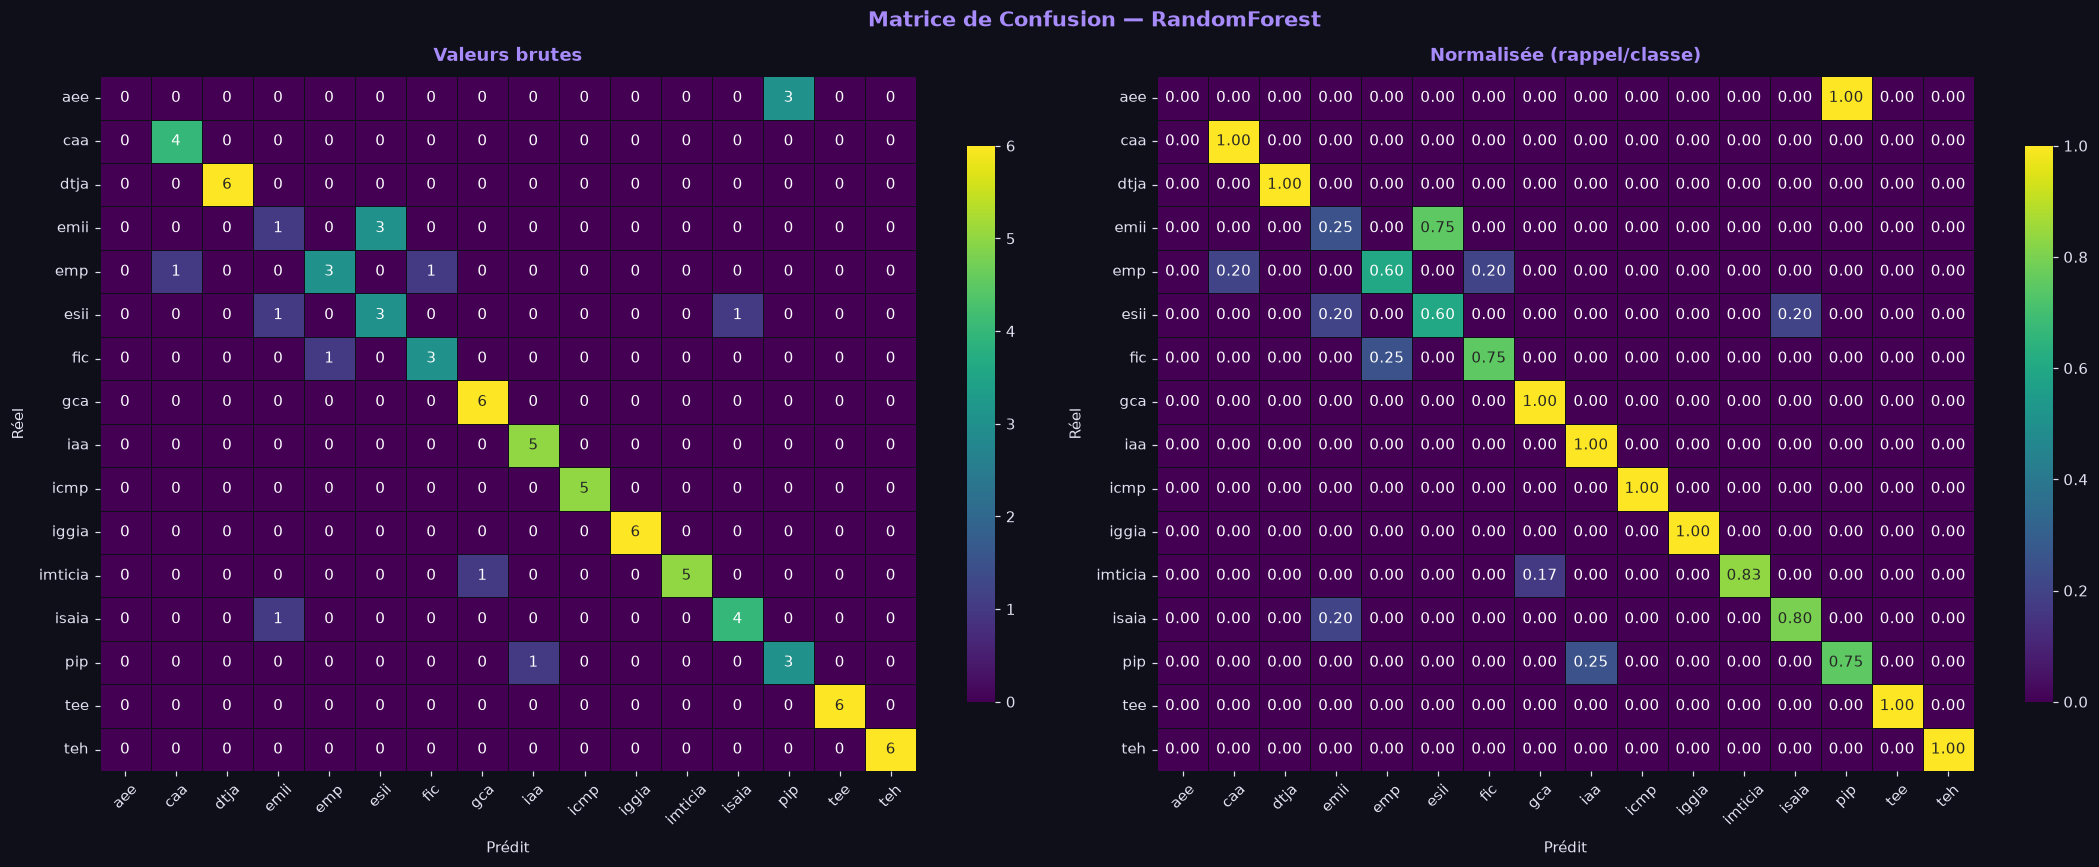

In [6]:
labels  = sorted(rf.classes_)
yp_rf   = rf.predict(Xte)
cm      = confusion_matrix(yte, yp_rf, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Matrice de Confusion — RandomForest', fontsize=14, fontweight='bold', color='#a78bfa')

for ax, data, title, fmt in [
    (axes[0], cm,      'Valeurs brutes',            'd'),
    (axes[1], cm_norm, 'Normalisée (rappel/classe)', '.2f')
]:
    sns.heatmap(data, annot=True, fmt=fmt, xticklabels=labels, yticklabels=labels,
                cmap='viridis', linewidths=0.4, linecolor='#0f0f1a',
                ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(title, color='#a78bfa', fontweight='bold', pad=10)
    ax.set_xlabel('Prédit', labelpad=8)
    ax.set_ylabel('Réel', labelpad=8)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 6. Rapport de Classification & F1 par Parcours

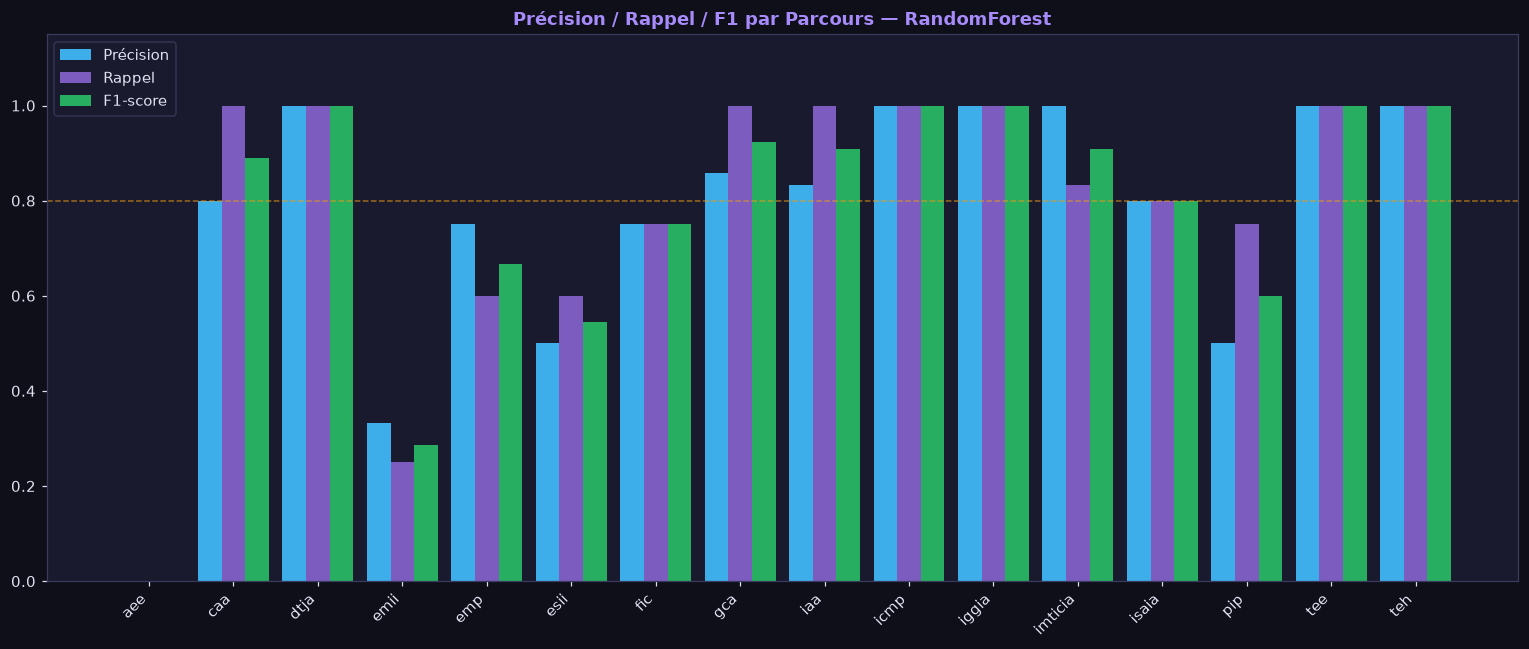

              precision    recall  f1-score   support

         aee       0.00      0.00      0.00         3
         caa       0.80      1.00      0.89         4
        dtja       1.00      1.00      1.00         6
        emii       0.33      0.25      0.29         4
         emp       0.75      0.60      0.67         5
        esii       0.50      0.60      0.55         5
         fic       0.75      0.75      0.75         4
         gca       0.86      1.00      0.92         6
         iaa       0.83      1.00      0.91         5
        icmp       1.00      1.00      1.00         5
       iggia       1.00      1.00      1.00         6
     imticia       1.00      0.83      0.91         6
       isaia       0.80      0.80      0.80         5
         pip       0.50      0.75      0.60         4
         tee       1.00      1.00      1.00         6
         teh       1.00      1.00      1.00         6

    accuracy                           0.82        80
   macro avg       0.76   

In [7]:
report_dict = classification_report(yte, yp_rf, labels=labels, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report_dict).T.drop(['accuracy','macro avg','weighted avg'], errors='ignore')
report_df = report_df[['precision','recall','f1-score','support']].astype(float)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(report_df))
w = 0.28
ax.bar(x-w, report_df['precision'], width=w, color='#3daee9', label='Précision')
ax.bar(x,   report_df['recall'],    width=w, color='#7c5cbf', label='Rappel')
ax.bar(x+w, report_df['f1-score'],  width=w, color='#27ae60', label='F1-score')
ax.set_xticks(x)
ax.set_xticklabels(report_df.index, rotation=45, ha='right')
ax.set_ylim(0, 1.15)
ax.set_title('Précision / Rappel / F1 par Parcours — RandomForest', color='#a78bfa', fontweight='bold')
ax.axhline(0.8, linestyle='--', color='#f39c12', linewidth=1, alpha=0.6)
ax.legend(facecolor='#1a1a2e', edgecolor='#3a3a5c')
plt.tight_layout()
plt.show()

print(classification_report(yte, yp_rf, labels=labels, zero_division=0))

## 7. Importance des Features (RandomForest — Top 20)

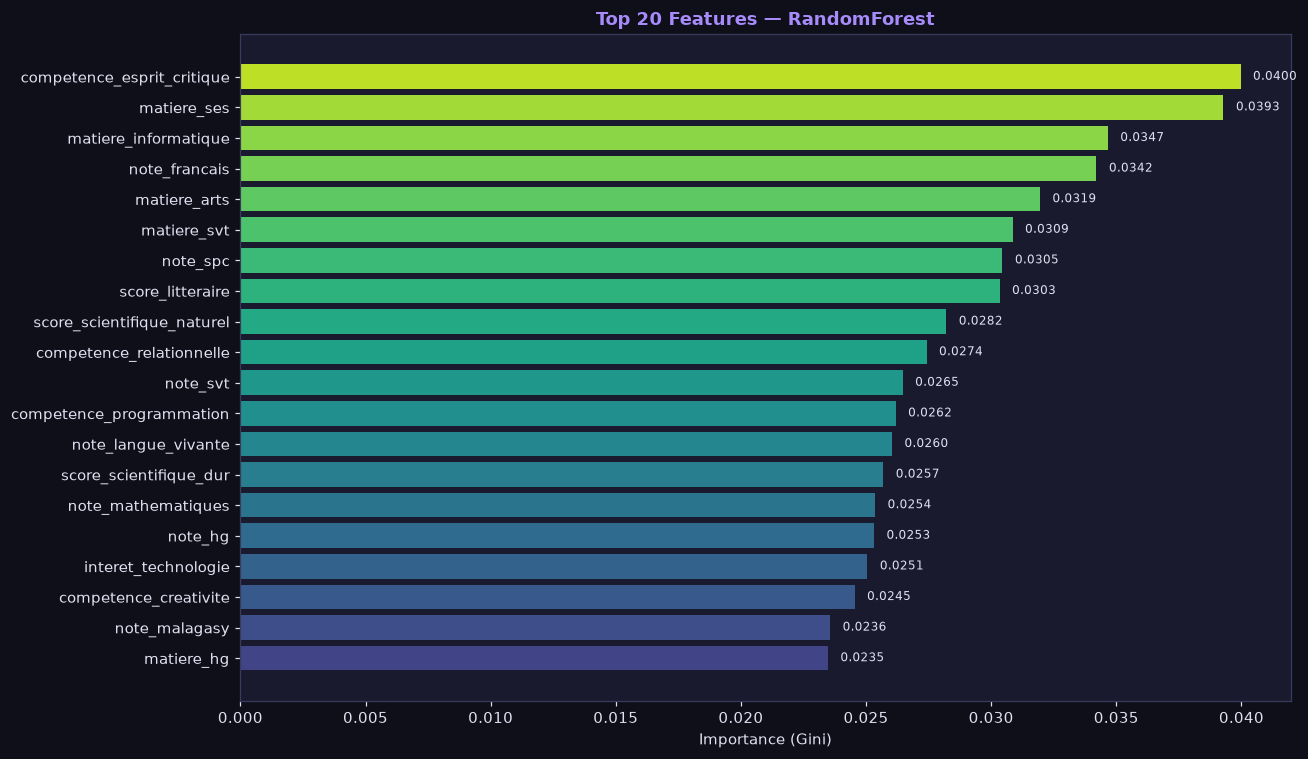

In [8]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
top20 = importances.head(20).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top20)))
ax.barh(top20.index, top20.values, color=colors, edgecolor='none')
ax.set_title('Top 20 Features — RandomForest', color='#a78bfa', fontweight='bold')
ax.set_xlabel('Importance (Gini)')
for v, bar in zip(top20.values, ax.patches):
    ax.text(v+0.0005, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Analyse de Biais — Accuracy par Groupe

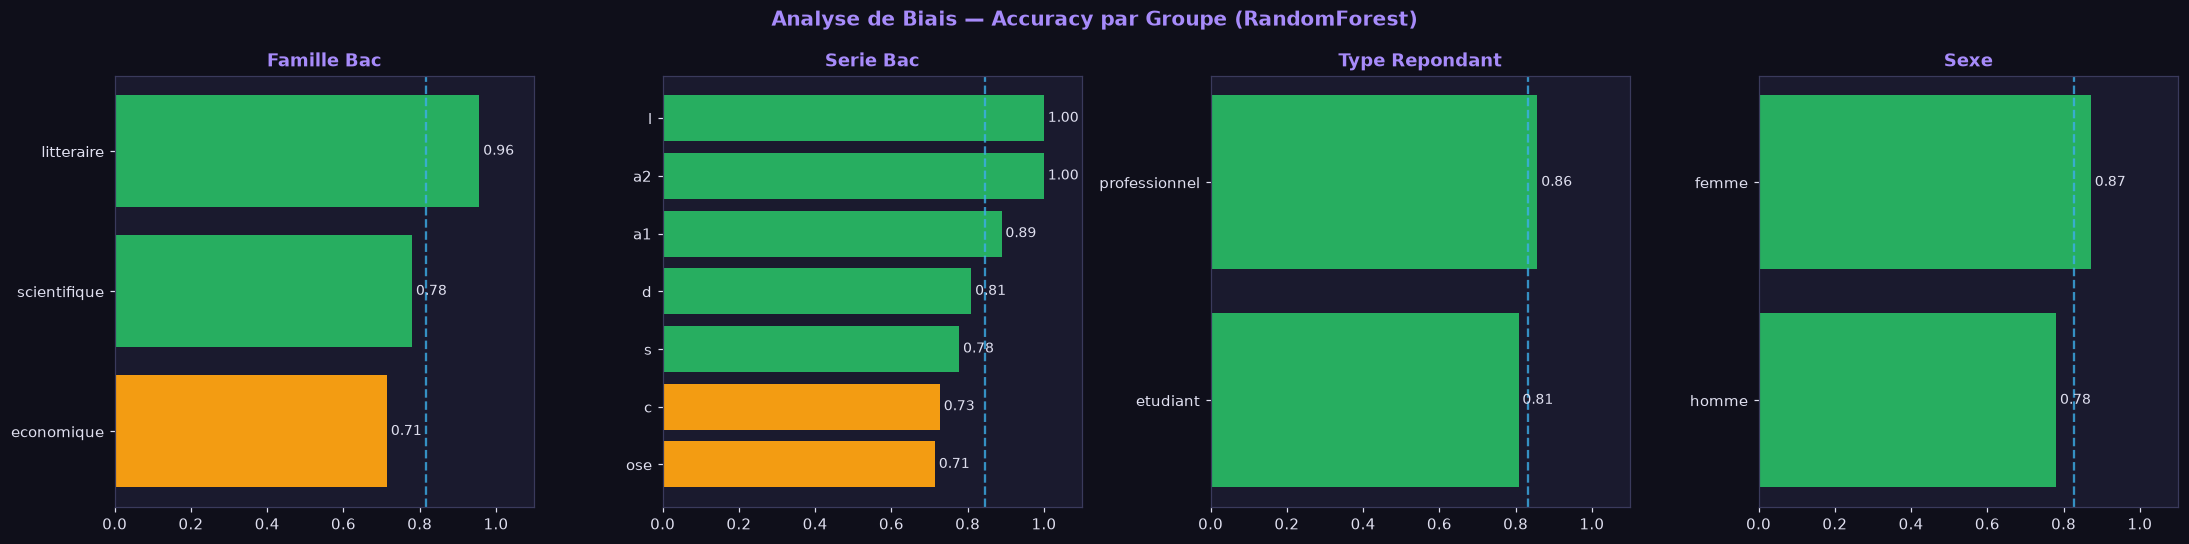

In [9]:
# Reconstruire les indices du split test (même random_state) pour aligner avec df
idx_all = np.arange(len(df))
idx_tr, idx_te = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y)
df_test = df.iloc[idx_te].copy()
df_test['prediction'] = yp_rf
df_test['ok'] = (df_test['parcours_choisi'].astype(str) == df_test['prediction']).astype(int)

groupes = ['famille_bac', 'serie_bac', 'type_repondant']
if 'sexe' in df_test.columns:
    groupes.append('sexe')

fig, axes = plt.subplots(1, len(groupes), figsize=(5*len(groupes), 5))
fig.suptitle('Analyse de Biais — Accuracy par Groupe (RandomForest)', fontsize=13,
             fontweight='bold', color='#a78bfa')

for ax, groupe in zip(axes, groupes):
    acc_g = df_test.groupby(groupe)['ok'].mean().sort_values(ascending=True)
    clrs  = [('#27ae60' if v >= 0.75 else '#f39c12' if v >= 0.5 else '#e74c3c') for v in acc_g.values]
    ax.barh(acc_g.index, acc_g.values, color=clrs, edgecolor='none')
    ax.set_title(groupe.replace('_',' ').title(), color='#a78bfa', fontweight='bold')
    ax.set_xlim(0, 1.1)
    ax.axvline(acc_g.mean(), linestyle='--', color='#3daee9', linewidth=1.5, alpha=0.8)
    for v, bar in zip(acc_g.values, ax.patches):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Sauvegarde du Modèle Entraîné

In [10]:
# Choisir le meilleur modèle (accuracy sur le jeu de test)
acc_rf = accuracy_score(yte, rf.predict(Xte))
acc_lr = accuracy_score(yte, lr.predict(Xte_imp))
if acc_rf >= acc_lr:
    best_name, best_model, best_acc = 'rf', rf, acc_rf
else:
    best_name, best_model, best_acc = 'lr', lr, acc_lr

payload = {
    'model':         best_model,
    'model_name':    best_name,
    'imputer':       imputer,
    'classes':       sorted(rf.classes_.tolist()),
    'feature_names': feature_names,
    'accuracy_test': round(best_acc, 4),
    'n_samples':     int(len(df)),
    'trained_at':    time.strftime('%Y-%m-%d %H:%M:%S'),
    'dataset_path':  str(Path(config.DATASET_PATH).name),
}

ml_path = config.ML_MODEL_PATH
model_path = Path(ml_path) if Path(ml_path).is_absolute() else Path('..') / ml_path
joblib.dump(payload, model_path)

print(f'✅ Modèle sauvegardé  →  {model_path.resolve()}')
print(f'   Modèle retenu      : {best_name.upper()}')
print(f'   Accuracy test      : {best_acc:.4f}')
print(f'   Nb profils train   : {len(Xtr)}')
print(f'   Nb features        : {len(feature_names)}')
print(f'   Nb classes         : {len(payload["classes"])}')
print(f'   Entraîné le        : {payload["trained_at"]}')

✅ Modèle sauvegardé  →  /home/tovo/Bureau/cliniqueExam/backend/ml_model.joblib
   Modèle retenu      : RF
   Accuracy test      : 0.8250
   Nb profils train   : 320
   Nb features        : 77
   Nb classes         : 16
   Entraîné le        : 2026-08-27 05:12:23


## 10. Conclusion & Limites

- Le modèle améliore largement la baseline (classe majoritaire).
- Les données sont **synthétiques** : les corrélations parcours → préférences sont volontairement fortes ; les vrais résultats devront être mesurés sur les réponses de l'enquête réelle (`data/enquete`).
- L'analyse de biais révèle une potentielle disparité d'accuracy selon la série de bac ou le genre : à surveiller sur des données réelles.
- Le rapport d'évaluation complet est généré par `python -m evaluation.run_evaluation`.
- Le modèle sauvegardé (`ml_model.joblib`) est directement chargé par le backend au prochain démarrage.